## Team STAR Part 1: Get comfortable using Tsim
![surface_code.png](./assets/surface_code.png)

Familiarize yourself with the surface code and its stabilizer structure. 
Use Tsim to construct a distance-3 surface code and simulate two rounds of syndrome extraction.

Start by identifying the data and ancilla qubits, the stabilizer checks being measured, and how syndrome information is extracted over time. 
Use this part to get comfortable building the code in Tsim, running repeated syndrome cycles, and understanding how errors affect the circuit.

**Goal:** Build intuition for the distance-3 surface code, repeated syndrome extraction, and the simulation workflow in Tsim.


In [ ]:
# Using Squin
from typing import Any

from bloqade import squin, tsim
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
# import tsim

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)


@squin.kernel
def bell_state() -> Measurement:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

show_circuit(bell_state)



In [13]:

def make_distance_n_surface(n):
    """
    Crea un kernel SQUIN per distance-n surface code.

    Ritorna:
        distance_n_surface: kernel SQUIN
        debug_text: stringa da stampare fuori dal kernel
    """

    z_supports, x_supports = build_stabilizer_supports(n)

    debug_text = surface_debug_text(n, z_supports, x_supports)

    num_data = n**2
    num_z = len(z_supports)
    num_x = len(x_supports)
    num_ancillas = num_z + num_x

    @squin.kernel
    def distance_n_surface():
        data_qubits = squin.qalloc(num_data)
        ancillas = squin.qalloc(num_ancillas)

        # Convenzione:
        # ancillas[0 : num_z] = Z ancillas
        # ancillas[num_z : num_z + num_x] = X ancillas

        # Reset data qubits
        for d in data_qubits:
            squin.reset(d)

        # Reset ancillas
        for a in ancillas:
            squin.reset(a)

        # Preparo le X ancillas in |+>
        for i in range(num_x):
            squin.h(ancillas[num_z + i])

        # =========================
        # Z stabilizers
        # =========================
        # Per misurare Z-parity:
        # data qubit = controllo
        # Z ancilla  = target

        for stab_idx in range(num_z):
            for data_idx in z_supports[stab_idx]:
                squin.cx(
                    data_qubits[data_idx],
                    ancillas[stab_idx],
                )

        # =========================
        # X stabilizers
        # =========================
        # Per misurare X-parity:
        # X ancilla  = controllo
        # data qubit = target

        for stab_idx in range(num_x):
            for data_idx in x_supports[stab_idx]:
                squin.cx(
                    ancillas[num_z + stab_idx],
                    data_qubits[data_idx],
                )

        # Riporto le X ancillas in base Z per misurarle
        for i in range(num_x):
            squin.h(ancillas[num_z + i])

        # Output:
        # risultati[0 : num_z] = sindromi Z
        # risultati[num_z : ]  = sindromi X
        return squin.broadcast.measure(ancillas)

    return distance_n_surface, debug_text

In [14]:
def build_stabilizer_supports(n):
    """
    Costruisce i supporti degli stabilizzatori per una rotated surface code n x n.

    Ritorna:
        z_supports: tuple di tuple
        x_supports: tuple di tuple

    Convenzione data qubit:
        0   1   2
        3   4   5
        6   7   8
    """

    if n < 3:
        raise ValueError("n deve essere almeno 3")

    if n % 2 == 0:
        raise ValueError("n deve essere dispari: 3, 5, 7, ...")

    expected = (n**2 - 1) // 2

    def q(row, col):
        return row * n + col

    z_supports = []
    x_supports = []

    # =========================
    # Z STABILIZERS
    # =========================

    # Bordo alto: coppie orizzontali
    for col in range(0, n - 1, 2):
        z_supports.append((
            q(0, col),
            q(0, col + 1),
        ))

    # Interni Z: plaquette 2x2 con parità dispari
    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                z_supports.append((
                    q(row, col),
                    q(row, col + 1),
                    q(row + 1, col),
                    q(row + 1, col + 1),
                ))

    # Bordo basso: coppie orizzontali sfalsate
    for col in range(1, n - 1, 2):
        z_supports.append((
            q(n - 1, col),
            q(n - 1, col + 1),
        ))

    # =========================
    # X STABILIZERS
    # =========================

    for row in range(n - 1):

        # Bordo sinistro: coppie verticali sfalsate
        if row % 2 == 1:
            x_supports.append((
                q(row, 0),
                q(row + 1, 0),
            ))

        # Interni X: plaquette 2x2 con parità pari
        for col in range(n - 1):
            if (row + col) % 2 == 0:
                x_supports.append((
                    q(row, col),
                    q(row, col + 1),
                    q(row + 1, col),
                    q(row + 1, col + 1),
                ))

        # Bordo destro: coppie verticali
        if row % 2 == 0:
            x_supports.append((
                q(row, n - 1),
                q(row + 1, n - 1),
            ))

    if len(z_supports) != expected:
        raise RuntimeError(
            f"Z stabilizers generati: {len(z_supports)}, attesi: {expected}"
        )

    if len(x_supports) != expected:
        raise RuntimeError(
            f"X stabilizers generati: {len(x_supports)}, attesi: {expected}"
        )

    return tuple(z_supports), tuple(x_supports)


def surface_debug_text(n, z_supports, x_supports):
    """
    Crea una stringa debug invece di stampare direttamente.
    In Jupyter è più affidabile: puoi fare print(debug_text).
    """

    lines = []

    lines.append("\nDATA QUBITS")
    lines.append("=" * 70)

    for row in range(n):
        line = "   ".join(f"{row * n + col:02d}" for col in range(n))
        lines.append(line)

    lines.append("\nZ STABILIZERS")
    lines.append("=" * 70)

    for i, support in enumerate(z_supports):
        lines.append(f"z_ancillas[{i:02d}] -> {list(support)}")

    lines.append("\nX STABILIZERS")
    lines.append("=" * 70)

    for i, support in enumerate(x_supports):
        lines.append(f"x_ancillas[{i:02d}] -> {list(support)}")

    lines.append("\nVISUAL MAP")
    lines.append("=" * 70)
    lines.append("D = data qubit, Z = stabilizzatore Z, X = stabilizzatore X\n")

    size = 2 * n + 1
    grid = [["." for _ in range(size)] for _ in range(size)]

    # Data qubits
    for row in range(n):
        for col in range(n):
            data_idx = row * n + col
            grid[2 * row + 1][2 * col + 1] = f"D{data_idx:02d}"

    # Z stabilizers
    z_counter = 0

    for col in range(0, n - 1, 2):
        grid[0][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                grid[2 * row + 2][2 * col + 2] = f"Z{z_counter:02d}"
                z_counter += 1

    for col in range(1, n - 1, 2):
        grid[2 * n][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    # X stabilizers
    x_counter = 0

    for row in range(n - 1):

        if row % 2 == 1:
            grid[2 * row + 2][0] = f"X{x_counter:02d}"
            x_counter += 1

        for col in range(n - 1):
            if (row + col) % 2 == 0:
                grid[2 * row + 2][2 * col + 2] = f"X{x_counter:02d}"
                x_counter += 1

        if row % 2 == 0:
            grid[2 * row + 2][2 * n] = f"X{x_counter:02d}"
            x_counter += 1

    for row in grid:
        lines.append("".join(f"{cell:>6}" for cell in row))

    return "\n".join(lines)

In [18]:
n = 3

distance_n_surface, debug_text = make_distance_n_surface(n)

print(debug_text)

In [8]:
####

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tsim

# ─────────────────────────────────────────────────────────────────────────────
# 1. Distance-3 Rotated Surface Code: qubit layout & stabilizers
# ─────────────────────────────────────────────────────────────────────────────
# Qubit indices follow the convention in the STAR stim circuits:
#   Data qubits   : 0–8  (3×3 grid, half-integer coordinates)
#   Z-ancillas    : 9–12 (measure Z⊗…⊗Z stabilizers)
#   X-ancillas    : 13–16 (measure X⊗…⊗X stabilizers)

data_qubits = list(range(9))
z_ancillas  = [9, 10, 11, 12]
x_ancillas  = [13, 14, 15, 16]

# Stabilizer support: which data qubits each ancilla couples to
z_stabs = {9: [0,1], 10: [1,2,4,5], 11: [3,4,6,7], 12: [7,8]}
x_stabs = {13: [0,1,3,4], 14: [2,5], 15: [3,6], 16: [4,5,7,8]}

# ─────────────────────────────────────────────────────────────────────────────
# 3. Build the syndrome extraction circuit using Tsim
# ─────────────────────────────────────────────────────────────────────────────
# CNOT schedule (4 parallel steps) from the reference STAR stim circuit:
#   CX ancilla → data   for X stabilisers  (propagates X errors to ancilla)
#   CX data → ancilla   for Z stabilisers  (propagates Z errors to ancilla)

CNOT_STEPS = [
    "CX 13 0  14 2  16 4   1 10   3 11   7 12",
    "CX 13 3  14 5  16 7   2 10   4 11   8 12",
    "CX 13 1  15 3  16 5   0 9    4 10   6 11",
    "CX 13 4  15 6  16 8   1 9    5 10   7 11",
]

def syndrome_round(noise_p: float = 0.0) -> str:
    """Return stim program text for one complete syndrome extraction round.

    Produces 8 measurement bits per shot:
        bits 0-3  →  Z-ancilla outcomes  (q9, q10, q11, q12)
        bits 4-7  →  X-ancilla outcomes  (q13, q14, q15, q16)
    """
    lines = [
        "R  9 10 11 12",    # Z ancillas → |0⟩
        "RX 13 14 15 16",   # X ancillas → |+⟩
        "TICK",
    ]
    all_q = " ".join(str(q) for q in range(17))
    for step in CNOT_STEPS:
        lines.append(step)
        if noise_p > 0:
            lines.append(f"DEPOLARIZE1({noise_p}) {all_q}")
        lines.append("TICK")
    lines += [
        "M  9 10 11 12",    # Z-basis measurement → syndrome bits
        "MX 13 14 15 16",   # X-basis measurement → syndrome bits
    ]
    return "\n".join(lines)

# ─────────────────────────────────────────────────────────────────────────────
# 4. Noiseless simulation: two syndrome rounds
# ─────────────────────────────────────────────────────────────────────────────
# Data qubits initialised in |0⟩:
#   • Z stabilisers are +1 eigenstates → all Z syndrome bits = 0
#   • X stabilisers are NOT +1 eigenstates of |0⟩ → first-round X outcome
#     is random, but the CHANGE between rounds must be 0 (no noise)

circuit_noiseless = tsim.Circuit(
    "R " + " ".join(str(q) for q in data_qubits) + "\n"
    "TICK\n"
    + syndrome_round() + "\n"
    "TICK\n"
    + syndrome_round()
)

print(f"\nNoiseless circuit: {circuit_noiseless.num_qubits} qubits, "
      f"{circuit_noiseless.num_measurements} measurements (8 per round × 2 rounds)")

sampler = circuit_noiseless.compile_sampler(seed=42)
shots = 8
raw = sampler.sample(shots).astype(int)

# Unpack: round 1 → cols 0-7, round 2 → cols 8-15
z_r1, x_r1 = raw[:, 0:4], raw[:, 4:8]
z_r2, x_r2 = raw[:, 8:12], raw[:, 12:16]

print("\n── Noiseless (8 shots) ──")
print("Round-1 Z syndromes [q9 q10 q11 q12]  (expect all 0):")
print(" ", z_r1)
print("Round-1 X syndromes [q13 q14 q15 q16]  (random – first projection):")
print(" ", x_r1)
print("Δ_Z = r2 ⊕ r1  (expect all 0):")
print(" ", z_r1 ^ z_r2)
print("Δ_X = r2 ⊕ r1  (expect all 0):")
print(" ", x_r1 ^ x_r2)

# ─────────────────────────────────────────────────────────────────────────────
# 5. Deterministic error: X flip on qubit 4 between the two rounds
# ─────────────────────────────────────────────────────────────────────────────
# X error on q4 anticommutes with every Z stabiliser that contains q4:
#   Z_10 = Z1·Z2·Z4·Z5  → fires  (Δ = 1)
#   Z_11 = Z3·Z4·Z6·Z7  → fires  (Δ = 1)
#   Z_9, Z_12           → silent
#   All X stabilisers commute with X error → Δ_X = 0

circuit_xerr = tsim.Circuit(
    "R " + " ".join(str(q) for q in data_qubits) + "\n"
    "TICK\n"
    + syndrome_round() + "\n"
    "TICK\n"
    "X_ERROR(1.0) 4\n"
    "TICK\n"
    + syndrome_round()
)

s_err = circuit_xerr.compile_sampler(seed=0).sample(4).astype(int)
dz = s_err[:, 8:12] ^ s_err[:, 0:4]
dx = s_err[:, 12:16] ^ s_err[:, 4:8]

print("\n── Deterministic X error on qubit 4 ──")
print("RAW: ", s_err)
print("Δ_Z [q9, q10, q11, q12]  (expect [0,1,1,0]):")
print(" ", dz)
print("Δ_X [q13, q14, q15, q16]  (expect [0,0,0,0]):")
print(" ", dx)

# ─────────────────────────────────────────────────────────────────────────────
# 6. Noisy simulation: DEPOLARIZE1(p), measure syndrome change rates
# ─────────────────────────────────────────────────────────────────────────────

p = 0.01
circuit_noisy = tsim.Circuit(
    "R " + " ".join(str(q) for q in data_qubits) + "\n"
    "TICK\n"
    + syndrome_round(noise_p=p) + "\n"
    "TICK\n"
    + syndrome_round(noise_p=p)
)

n_shots = 2000
s_noisy = circuit_noisy.compile_sampler(seed=7).sample(n_shots).astype(int)
dz_noisy = s_noisy[:, 8:12] ^ s_noisy[:, 0:4]
dx_noisy = s_noisy[:, 12:16] ^ s_noisy[:, 4:8]

print(f"\n── Depolarising noise p = {p}, N = {n_shots} shots ──")
print("Z-ancilla syndrome change rates  (heavier stabilisers fire more often):")
for i, (anc, label) in enumerate({9:"Z_9", 10:"Z_10", 11:"Z_11", 12:"Z_12"}.items()):
    rate = dz_noisy[:, i].mean()
    print(f"  {label} (data {z_stabs[anc]}, weight {len(z_stabs[anc])}): {rate:.3f}")
print("X-ancilla syndrome change rates:")
for i, (anc, label) in enumerate({13:"X_13", 14:"X_14", 15:"X_15", 16:"X_16"}.items()):
    rate = dx_noisy[:, i].mean()
    print(f"  {label} (data {x_stabs[anc]}, weight {len(x_stabs[anc])}): {rate:.3f}")


def print_surface_debug(n, z_supports, x_supports):
    print("\nDATA QUBITS")
    print("=" * 60)

    for row in range(n):
        print("   ".join(f"{row * n + col:02d}" for col in range(n)))

    print("\nZ STABILIZERS")
    print("=" * 60)

    for i, support in enumerate(z_supports):
        print(f"z_ancillas[{i}] -> {list(support)}")

    print("\nX STABILIZERS")
    print("=" * 60)

    for i, support in enumerate(x_supports):
        print(f"x_ancillas[{i}] -> {list(support)}")

    print("\nVISUAL MAP")
    print("=" * 60)
    print("D = data qubit, Z = Z stabilizer, X = X stabilizer\n")

    size = 2 * n + 1
    grid = [["." for _ in range(size)] for _ in range(size)]

    # Data qubits
    for row in range(n):
        for col in range(n):
            data_idx = row * n + col
            grid[2 * row + 1][2 * col + 1] = f"D{data_idx:02d}"

    # Z positions
    z_counter = 0

    for col in range(0, n - 1, 2):
        grid[0][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                grid[2 * row + 2][2 * col + 2] = f"Z{z_counter:02d}"
                z_counter += 1

    for col in range(1, n - 1, 2):
        grid[2 * n][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    # X positions
    x_counter = 0

    for row in range(n - 1):
        if row % 2 == 1:
            grid[2 * row + 2][0] = f"X{x_counter:02d}"
            x_counter += 1

        for col in range(n - 1):
            if (row + col) % 2 == 0:
                grid[2 * row + 2][2 * col + 2] = f"X{x_counter:02d}"
                x_counter += 1

        if row % 2 == 0:
            grid[2 * row + 2][2 * n] = f"X{x_counter:02d}"
            x_counter += 1

    for row in grid:
        print("".join(f"{cell:>6}" for cell in row))



Noiseless circuit: 17 qubits, 16 measurements (8 per round × 2 rounds)

── Noiseless (8 shots) ──
Round-1 Z syndromes [q9 q10 q11 q12]  (expect all 0):
  [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Round-1 X syndromes [q13 q14 q15 q16]  (random – first projection):
  [[0 0 0 1]
 [0 1 0 1]
 [1 1 1 0]
 [0 1 1 1]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 0 0]
 [0 1 1 1]]
Δ_Z = r2 ⊕ r1  (expect all 0):
  [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Δ_X = r2 ⊕ r1  (expect all 0):
  [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

── Deterministic X error on qubit 4 ──
RAW:  [[0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 1 0 1 0 0 1 1 0 1 0 1 0]
 [0 0 0 0 0 0 1 1 0 1 1 0 0 0 1 1]]
Δ_Z [q9, q10, q11, q12]  (expect [0,1,1,0]):
  [[0 1 1 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 1 1 0]]
Δ_X [q13, q14, q15, q16]  (expect [0,0,0,0]):
  [[0 0 0 0]
 [0 0 0 0]
 [0 

KeyboardInterrupt: 

## Team STAR Part 2: Estimate STAR Fidelities
Review the STAR circuits that have been provided in the assets folder and use Tsim to simulate them in a noisy setting. 
Reproduce the fidelity plot below using data from your Tsim simulations.

![star_sim.svg](./assets/star_sim.svg)

The provided circuits are for a default rotation angle of 0.01*pi. To simulate different rotation angles, you can use the following function to compute the physical rotation angle needed to achieve a logical rotation of angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

Also make sure to check out the comments in `circuits/star_d=3.stim` to get some hints about the circuit structure.

**Goal:** Learn how to load and run pre-built circuits using Tsim. 


In [ ]:
# Note: This is a STAR circuit for preparing a single logical qubit in the |+> state
# that has been rotated by 0.01*pi around the Z axis.

# The steps are:

# 1. Initialize a logical |+> state 
# 2. Perform d physical rotations
# 3. Perform two rounds of stabilizer measurement
# 4. Now post-select on perfect stabilizers
# 5. Perform d rounds of stabilizer measurement
# 6. Perform a perfect logical unrotation (this is impossible on a real quantum computer, but works in a simulation). 

# In the ideal case, this would bring us back to the logical |+> state. If we measure the logical |+>, we should obtain the result 0.
# If we get a 1, we know that a logical error has occurred. This is a simple way to check for logical errors in a simulation.

# Building in Squin
initial_surface(d=3)


In [ ]:
# Using import from_file

import stim
import matplotlib.pyplot as plt

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)


def load_star_circuit(d: int, logical_angle_in_pi: float) -> tsim.Circuit:
    base = tsim.Circuit.from_file(f"assets/star_circuits/star_d={d}.stim")
    new_phys = physical_angle(logical_angle_in_pi, d)

    patched = stim.Circuit()
    for instr in base:
        if instr.name == "I" and instr.tag and instr.tag.startswith("R_Z("):
            targets = [t.value for t in instr.targets_copy()]
            # d targets → physical transversal rotation; 1 target → logical unrotation
            tag = (f"R_Z(theta={new_phys}*pi)" if len(targets) == d
                   else f"R_Z(theta={-logical_angle_in_pi}*pi)")
            patched.append("I", targets, tag=tag)
        else:
            patched.append(instr)

    return tsim.Circuit.from_stim_program(patched)

def dump(circuit, filename="./temp.txt"):
    with open(filename, mode="w") as f:
        for instr in circuit:
            f.write(str(instr))
            f.write("\n")

# Dump
base = tsim.Circuit.from_file(f"assets/star_circuits/star_d=3.stim")
dump(base, "base.txt")
dump(load_star_circuit(d=3, logical_angle_in_pi=0.5))

# part 2


/tmp/ipykernel_5402/4098493697.py:18: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


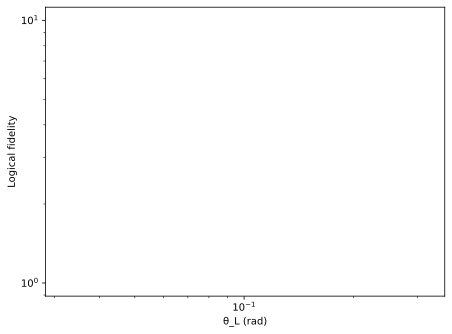

In [71]:
shots = 500
angles_pi = np.linspace(0, 1/np.pi, 11)   # logical angle in units of π
for d in [3,5,7]:    
    log_errors = []

    for angle in angles_pi:
        circ = load_star_circuit(d=d, logical_angle_in_pi=angle)
        sampler = circ.compile_detector_sampler(seed=42)
        dets, obs = sampler.sample(shots, separate_observables=True)
        clean = (dets == 0).all(axis=1)
        err = obs[clean, 0].mean() if clean.sum() > 0 else np.nan
        log_errors.append(err)

    plt.loglog(angles_pi, log_errors)

plt.xlabel("θ_L (rad)")
plt.ylabel("Logical fidelity")
plt.tight_layout()
plt.show()

## Team STAR Part 3 — Teleport a non-Clifford rotation into a logical qubit
Now assume a noiseless setting but where non-Clifford gates cannot be applied directly to the main logical qubit. 
Construct a protocol that uses an ancillary logical qubit to teleport a small-angle rotation into the main qubit while assuming the STAR transversal architecture.
Important: you will need to use postselection to filter results because Tsim (unlike PyQrack) does not support feed-forwarded operations.

![rus.png](./assets/rus.png)

Figure taken from *"Partially Fault-Tolerant Quantum Computing Architecture with Error-Corrected Clifford Gates and Space-Time Efficient Analog Rotations"* by *Akahoshi et al.*

**Goal:** Show how STAR enables indirect implementation of small-angle non-Clifford logical rotations, and analyze the costs of doing so. 


In [ ]:
# part 3